# 04 - Feature Engineering

## Objective

The purpose of this notebook is to:

- Identify useful input features
- Create meaningful derived health features
- Remove unnecessary or redundant features where appropriate
- Prepare the final feature set for preprocessing and model training

In [51]:
import pandas as pd
import numpy as np

In [52]:
df = pd.read_csv("../data/interim/clean_health_data.csv")

In [53]:
print("DataFrame Shape:", df.shape)

df.head()


DataFrame Shape: (97297, 34)


,Unnamed: 0,Age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,...,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,hypertension_risk_score,heart_disease_risk_score,obesity_risk_score,cholesterol_risk_score
0,0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,...,145,136,236,6.36,8.18,51.716583,53.581369,50.796020,57.387241,51.492983
1,1,52,Female,White,Highschool,Middle,Employed,Former,1,143,...,30,93,150,2.00,5.63,26.096162,47.946740,23.853485,36.219202,3.984993
2,2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,...,36,118,195,5.07,7.51,54.830087,42.141104,38.977694,42.898797,21.793300
3,3,74,Female,Black,Highschool,Low,Retired,Never,0,49,...,140,139,253,5.28,9.03,60.729521,60.286946,53.579555,52.194082,22.962029
4,4,46,Male,White,Graduate,Middle,Retired,Never,1,109,...,160,137,184,12.74,7.20,32.778085,15.279074,18.721942,32.095465,34.296907


In [54]:
#Define Target Variables
target_columns = [
    "diabetes_risk_score",
    "hypertension_risk_score",
    "heart_disease_risk_score",
    "obesity_risk_score",
    "cholesterol_risk_score"
]

In [55]:
#Separate Features and Targets

X = df.drop(columns=target_columns)
y = df[target_columns]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (97297, 29)
y shape: (97297, 5)


In [56]:
#Inspect Current Features
print(X.columns.tolist())

['Unnamed: 0', 'Age', 'gender', 'ethnicity', 'education_level', 'income_level', 'employment_status', 'smoking_status', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides', 'glucose_fasting', 'glucose_postprandial', 'insulin_level', 'hba1c']


Feature Engineering

In [57]:
#Create Pulse Pressure

X["pulse_pressure"] = (
    X["systolic_bp"] - X["diastolic_bp"]
)

X[[
    "systolic_bp",
    "diastolic_bp",
    "pulse_pressure"
]].head()

,systolic_bp,diastolic_bp,pulse_pressure
0,134,78,56
1,129,76,53
2,115,73,42
3,120,93,27
4,92,67,25


In [58]:
#Create BMI Category

def classify_bmi(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif bmi < 25:
        return "Normal"
    elif bmi < 30:
        return "Overweight"
    else:
        return "Obese"

X["bmi_category"] = X["bmi"].apply(classify_bmi)

print(X["bmi_category"].value_counts())

bmi_category
Overweight     44744
Normal         39231
Obese          11094
Underweight     2228
Name: count, dtype: int64


In [59]:
#Create Mean Blood Pressure

X["mean_arterial_pressure"] = (
    X["diastolic_bp"] +
    (X["systolic_bp"] - X["diastolic_bp"]) / 3
)

X[[
    "systolic_bp",
    "diastolic_bp",
    "mean_arterial_pressure"
]].head()

,systolic_bp,diastolic_bp,mean_arterial_pressure
0,134,78,96.666667
1,129,76,93.666667
2,115,73,87.000000
3,120,93,102.000000
4,92,67,75.333333


In [61]:
#Create Glucose Difference

X["glucose_difference"] = (
    X["glucose_postprandial"] -
    X["glucose_fasting"]
)

X[[
    "glucose_fasting",
    "glucose_postprandial",
    "glucose_difference"
]].head()

,glucose_fasting,glucose_postprandial,glucose_difference
0,136,236,100
1,93,150,57
2,118,195,77
3,139,253,114
4,137,184,47


In [62]:
#Create Cholesterol Ratio

X["total_to_hdl_ratio"] = (
    X["cholesterol_total"] /
    X["hdl_cholesterol"].replace(0, np.nan)
)

X[[
    "cholesterol_total",
    "hdl_cholesterol",
    "total_to_hdl_ratio"
]].head()

print(
    "Missing values in total_to_hdl_ratio:",
    X["total_to_hdl_ratio"].isnull().sum()
)

Missing values in total_to_hdl_ratio: 0


In [63]:
#Create Activity Level

X["activity_level"] = pd.cut(
    X["physical_activity_minutes_per_week"],
    bins=[-np.inf, 150, 300, np.inf],
    labels=["Low", "Moderate", "High"]
)

print(X["activity_level"].value_counts())

activity_level
Low         69870
Moderate    23614
High         3813
Name: count, dtype: int64


In [64]:
#Create Sleep Category

X["sleep_category"] = pd.cut(
    X["sleep_hours_per_day"],
    bins=[-np.inf, 6, 9, np.inf],
    labels=["Low", "Optimal", "High"]
)

print(X["sleep_category"].value_counts())

sleep_category
Optimal    75553
Low        18796
High        2948
Name: count, dtype: int64


In [65]:
#Check the New Features

print("Number of features:", X.shape[1])

print(X.columns.tolist())

Number of features: 36
['Unnamed: 0', 'Age', 'gender', 'ethnicity', 'education_level', 'income_level', 'employment_status', 'smoking_status', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides', 'glucose_fasting', 'glucose_postprandial', 'insulin_level', 'hba1c', 'pulse_pressure', 'bmi_category', 'mean_arterial_pressure', 'glucose_difference', 'total_to_hdl_ratio', 'activity_level', 'sleep_category']


In [66]:
#Check New Feature Statistics

X.describe()

,Unnamed: 0,Age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,...,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,pulse_pressure,mean_arterial_pressure,glucose_difference,total_to_hdl_ratio
count,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,...,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000
mean,48648.000000,50.192699,2.004543,118.942886,5.995214,6.997708,5.997031,0.219657,0.250912,0.079067,...,103.000308,121.466407,111.121792,160.014348,9.063591,6.520338,40.566163,88.756019,48.892556,3.587846
std,28087.368908,15.492557,1.418060,84.441920,1.780096,1.093726,2.469805,0.414017,0.433540,0.269845,...,33.390145,43.393422,13.590382,30.938915,4.956342,0.813710,15.469734,7.730879,25.424843,1.026275
min,0.000000,19.000000,0.000000,0.000000,0.000000,3.000000,0.500000,0.000000,0.000000,0.000000,...,50.000000,30.000000,60.000000,70.000000,2.000000,4.000000,-10.000000,63.333333,-45.000000,1.093750
25%,24324.000000,38.000000,1.000000,57.000000,4.800000,6.300000,4.300000,0.000000,0.000000,0.000000,...,78.000000,91.000000,102.000000,139.000000,5.090000,5.970000,30.000000,83.333333,32.000000,2.881356
50%,48648.000000,51.000000,2.000000,100.000000,6.000000,7.000000,6.000000,0.000000,0.000000,0.000000,...,102.000000,121.000000,111.000000,160.000000,8.790000,6.520000,40.000000,88.666667,49.000000,3.437500
75%,72972.000000,61.000000,3.000000,160.000000,7.200000,7.700000,7.700000,0.000000,1.000000,0.000000,...,126.000000,151.000000,120.000000,181.000000,12.450000,7.070000,51.000000,94.000000,66.000000,4.115385
max,97296.000000,90.000000,10.000000,833.000000,10.000000,10.000000,16.800000,1.000000,1.000000,1.000000,...,263.000000,344.000000,172.000000,287.000000,32.220000,9.800000,117.000000,122.666667,153.000000,12.681818


In [67]:
#Check Correlation Between Features

correlation_matrix = X.select_dtypes(
    include=["int64", "float64"]
).corr()

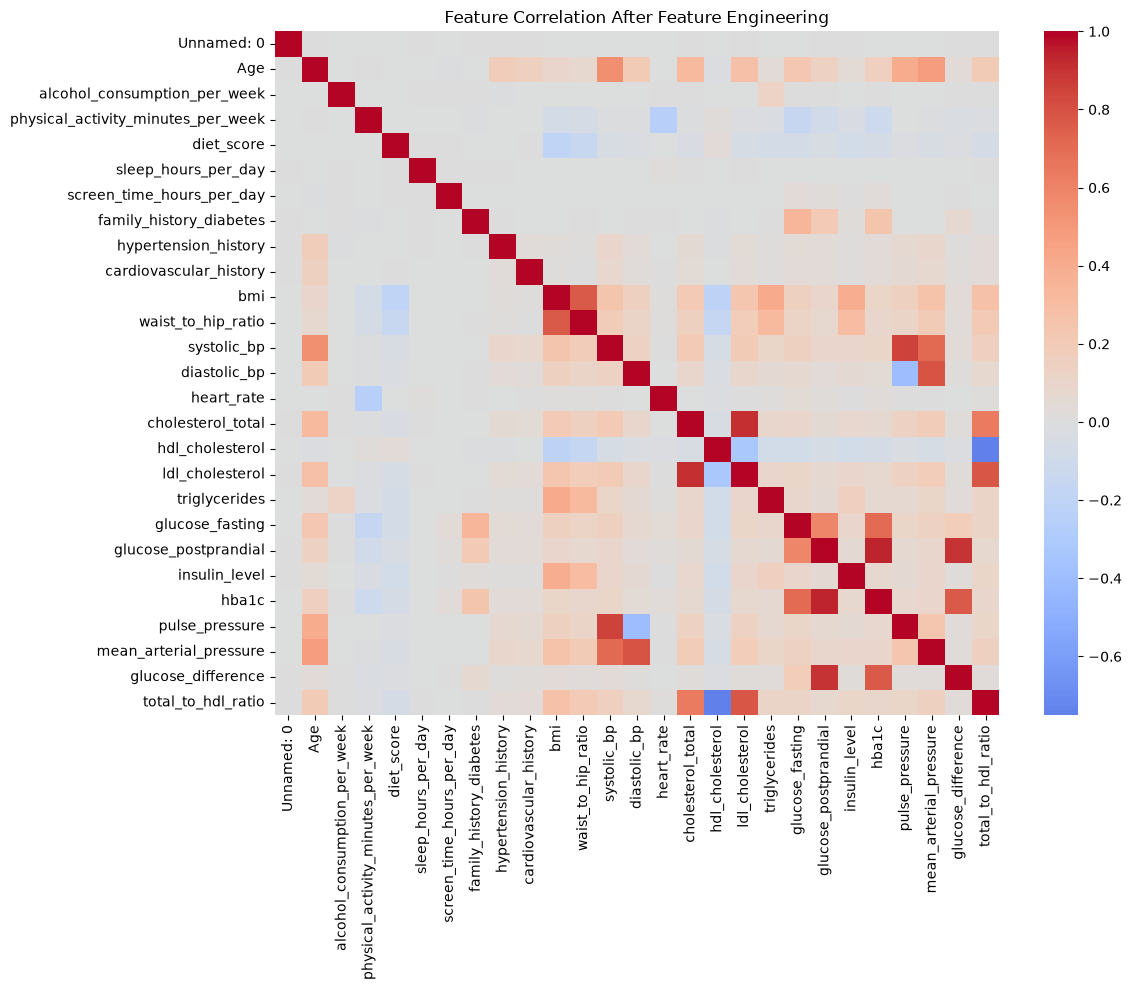

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation After Feature Engineering")
plt.tight_layout()
plt.show()

In [69]:
# Numerical engineered features
numerical_feature_columns = X.select_dtypes(
    include=np.number
).columns.tolist()

# Feature-target correlation
feature_target_correlation = (
    pd.concat([X[numerical_feature_columns], y], axis=1)
    .corr()
    .loc[numerical_feature_columns, target_columns]
)

feature_target_correlation

,diabetes_risk_score,hypertension_risk_score,heart_disease_risk_score,obesity_risk_score,cholesterol_risk_score
Unnamed: 0,0.003502,0.000190,0.001516,-0.000210,0.003313
Age,0.414791,0.735870,0.798682,0.080005,0.253711
alcohol_consumption_per_week,0.007587,-0.001765,0.000942,-0.001563,0.014271
physical_activity_minutes_per_week,-0.354322,-0.080789,-0.035776,-0.400444,-0.020766
diet_score,-0.115852,-0.077401,-0.037355,-0.195800,-0.061508
sleep_hours_per_day,0.003137,-0.002637,-0.002709,0.002236,0.001983
screen_time_hours_per_day,0.006196,-0.006408,-0.002240,0.065911,0.000890
family_history_diabetes,0.561887,-0.001910,0.060502,0.003778,0.001346
hypertension_history,0.076665,0.132185,0.142361,0.013318,0.042620
cardiovascular_history,0.062451,0.107532,0.119702,0.007591,0.036128


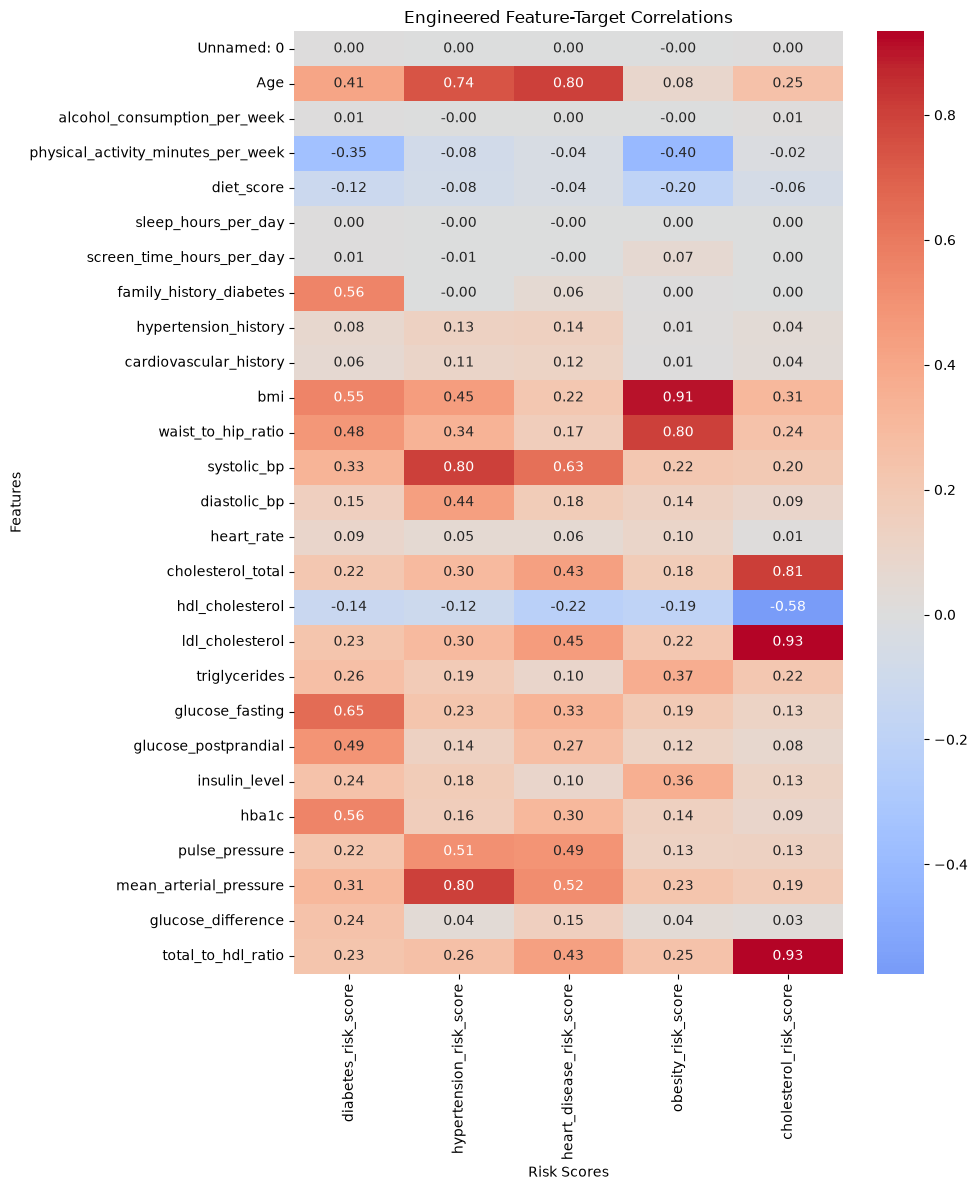

In [70]:
#Visualize Feature-Target Correlations

plt.figure(figsize=(10, 12))

sns.heatmap(
    feature_target_correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Engineered Feature-Target Correlations")
plt.xlabel("Risk Scores")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

In [72]:
#Feature Selection

final_features = X.columns.tolist()

print("Final number of features:", len(final_features))
print("\nFinal features:")

for feature in final_features:
    print("-", feature)

Final number of features: 36

Final features:
- Unnamed: 0
- Age
- gender
- ethnicity
- education_level
- income_level
- employment_status
- smoking_status
- alcohol_consumption_per_week
- physical_activity_minutes_per_week
- diet_score
- sleep_hours_per_day
- screen_time_hours_per_day
- family_history_diabetes
- hypertension_history
- cardiovascular_history
- bmi
- waist_to_hip_ratio
- systolic_bp
- diastolic_bp
- heart_rate
- cholesterol_total
- hdl_cholesterol
- ldl_cholesterol
- triglycerides
- glucose_fasting
- glucose_postprandial
- insulin_level
- hba1c
- pulse_pressure
- bmi_category
- mean_arterial_pressure
- glucose_difference
- total_to_hdl_ratio
- activity_level
- sleep_category


In [73]:
#Separate Final X and y

X_final = X[final_features]
y_final = y[target_columns]

print("X_final:", X_final.shape)
print("y_final:", y_final.shape)

X_final: (97297, 36)
y_final: (97297, 5)


In [74]:
# Check missing values
missing_values = X.isnull().sum().sum()

# Check infinite values
numeric_X = X.select_dtypes(include=np.number)

infinite_values = np.isinf(numeric_X).sum().sum()

print("Total missing values:", missing_values)
print("Total infinite values:", infinite_values)

# Check for duplicate features
print("Duplicate feature names:", X.columns.duplicated().sum())

Total missing values: 0
Total infinite values: 0
Duplicate feature names: 0


In [75]:
#final feature summary

feature_summary = pd.DataFrame({
    "Feature": X.columns,
    "Data Type": X.dtypes.astype(str).values,
    "Missing Values": X.isnull().sum().values,
    "Unique Values": X.nunique().values
})

feature_summary

,Feature,Data Type,Missing Values,Unique Values
0,Unnamed: 0,int64,0,97297
1,Age,int64,0,70
2,gender,str,0,3
3,ethnicity,str,0,5
4,education_level,str,0,4
5,income_level,str,0,5
6,employment_status,str,0,4
7,smoking_status,str,0,3
8,alcohol_consumption_per_week,int64,0,11
9,physical_activity_minutes_per_week,int64,0,618


In [76]:
# Save Final Feature and Target Datasets

X_final.to_csv(
    "../data/processed/final_features.csv",
    index=False
)

y_final.to_csv(
    "../data/processed/targets.csv",
    index=False
)

In [ ]:
# Verify Saved Datasets

X_check = pd.read_csv(
    "../data/processed/final_features.csv"
)

y_check = pd.read_csv(
    "../data/processed/targets.csv"
)

print("Features shape:", X_check.shape)
print("Targets shape:", y_check.shape)

print("\nNumber of feature columns:", X_check.shape[1])
print("Number of target columns:", y_check.shape[1])

print("\nTarget columns:")
print(y_check.columns.tolist())

# Check row alignment
if len(X_check) == len(y_check):
    print("\nX and y row counts match.")
else:
    print("\nERROR: X and y row counts do not match.")

# Check target leakage
target_overlap = set(X_check.columns).intersection(
    set(y_check.columns)
)

if len(target_overlap) == 0:
    print("No target leakage detected.")
else:
    print("WARNING: Target leakage detected")
    print("Overlapping columns:", target_overlap)

Features shape: (97297, 36)
Targets shape: (97297, 5)

Number of feature columns: 36
Number of target columns: 5

Target columns:
['diabetes_risk_score', 'hypertension_risk_score', 'heart_disease_risk_score', 'obesity_risk_score', 'cholesterol_risk_score']

X and y row counts match.
No target leakage detected.


In [79]:
import joblib

# Get final feature column order
feature_columns = X_final.columns.tolist()

# Save feature column names
joblib.dump(
    feature_columns,
    "../models/feature_columns.pkl"
)

print("Feature column list saved successfully.")
print("Number of features:", len(feature_columns))

Feature column list saved successfully.
Number of features: 36


In [80]:
print("\nSaved feature columns:")

for i, feature in enumerate(feature_columns, start=1):
    print(f"{i}. {feature}")


Saved feature columns:
1. Unnamed: 0
2. Age
3. gender
4. ethnicity
5. education_level
6. income_level
7. employment_status
8. smoking_status
9. alcohol_consumption_per_week
10. physical_activity_minutes_per_week
11. diet_score
12. sleep_hours_per_day
13. screen_time_hours_per_day
14. family_history_diabetes
15. hypertension_history
16. cardiovascular_history
17. bmi
18. waist_to_hip_ratio
19. systolic_bp
20. diastolic_bp
21. heart_rate
22. cholesterol_total
23. hdl_cholesterol
24. ldl_cholesterol
25. triglycerides
26. glucose_fasting
27. glucose_postprandial
28. insulin_level
29. hba1c
30. pulse_pressure
31. bmi_category
32. mean_arterial_pressure
33. glucose_difference
34. total_to_hdl_ratio
35. activity_level
36. sleep_category


In [81]:
# Verify saved feature columns

loaded_feature_columns = joblib.load(
    "../models/feature_columns.pkl"
)

print("Number of loaded features:", len(loaded_feature_columns))

Number of loaded features: 36


In [82]:
target_columns = [
    "diabetes_risk_score",
    "hypertension_risk_score",
    "heart_disease_risk_score",
    "obesity_risk_score",
    "cholesterol_risk_score"
]

# Save target column names

joblib.dump(
    target_columns,
    "../models/target_columns.pkl"
)

print("Target column list saved successfully.")

Target column list saved successfully.


# Feature Engineering Summary

## Original Features

The original dataset contained 28 input features and 5 target variables.

## Engineered Features

The following features were created:

- pulse_pressure
- bmi_category
- mean_arterial_pressure
- activity_level
- glucose_difference
- total_to_hdl_ratio
- sleep_category

## Validation

- Missing values were checked.
- Infinite values were checked.
- Feature statistics were examined.
- Feature correlations were analyzed.
- Feature-target correlations were investigated.
- Target leakage was checked to ensure that the five risk-score targets were not included in the input feature dataset.

## Output

The final feature dataset was saved to:

`data/processed/final_features.csv`

The target dataset was saved to:

`data/processed/targets.csv`

The feature column names were saved to:

`models/feature_columns.pkl`

The target column names were saved to:

`models/target_columns.pkl`